## Reto de la semana 6
Diego Andrés Burbano A.

In [186]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from google.colab import drive, files

%matplotlib inline

In [187]:
# Montaje del drive
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/datos')

data = pd.read_csv('./BreastCancer.csv', sep=',')

Mounted at /content/drive


In [188]:
data.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [189]:
data.shape

(469, 3)

Conservamos los resultados del reto anterior (reto 5) para comparar los resultados de los dos metodos:

In [190]:
# a) Definir la función para calcular f(w)
def calcular_f(w, data):
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values
    m = len(t)
    f_w = 0
    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        f_w += t[i] * np.log(y_i) + (1 - t[i]) * np.log(1 - y_i)

    f_w = -f_w / m
    return f_w

# Definimos los límites:
boundaries = [(None, None), (None, None), (None, None)]

# Condiciones iniciales
x0 = [0, 0, 0]
trayectoria = []

# Función callback que guarda cada w explorado
def callback(w):
    trayectoria.append(w)

# Ejecutamos minimize sin restricciones
res = minimize(calcular_f, x0, args=(data,), bounds=boundaries, callback = callback)

print("Resultado final:")
print(res)

Resultado final:
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.20464127038690735
        x: [ 5.359e+00  1.641e+00  2.444e-01]
      nit: 12
      jac: [ 1.332e-07 -8.049e-08 -1.388e-08]
     nfev: 56
     njev: 14
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [191]:
# Almacenamos en la variable 'mejor_w' el mejor punto que arroja el minimizador
print("Mejor valor de w encontrado:")
mejor_w = res.x
print(mejor_w)

Mejor valor de w encontrado:
[5.35902853 1.64129491 0.2444218 ]


Algoritmo de Descenso de Gradiente:

In [192]:
# Definir función
def funcion_objetivo(w, data):
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values
    m = len(t)
    f_w = 0
    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        f_w += t[i] * np.log(y_i) + (1 - t[i]) * np.log(1 - y_i)

    f_w = -f_w / m
    return f_w

# Gradiente de la funcion
def gradiente(w, data):
    # Extraer características y etiquetas
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values

    m = len(t)
    n = len(w)
    grad = np.zeros(n)

    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        y_i = np.clip(y_i, 1e-15, 1 - 1e-15)

        # Gradiente
        grad += (y_i - t[i]) * z_i


    grad = grad / m

    return grad


In [193]:
def desc_grad(x0,alpha,Nmax,epsilon,data):
  hist = [x0]                  # Historial iniciando con condicion inicial
  hist_fun = [funcion_objetivo(x0, data)] # Historial de función objetivo iniciando con la funcion evaluada en la condicion inicial
  converge = False
  k = 0
  while k<=Nmax:
    x_n = hist[k] - alpha*gradiente(hist[k], data)   # Regla principal de actualizacion
    hist.append(x_n)
    hist_fun.append(funcion_objetivo(x_n, data))
    if np.linalg.norm(hist[k+1] - hist[k]) <= epsilon: # Criterio de parada
      converge=True
      break
    k+=1
  return hist,hist_fun,converge

In [194]:
#Se declaran los parámetros establecidos en el enunciado del ejemplo
Nmax=1000              # Numero maximo de iteraciones
epsilon=0.0000001      # Umbral para condicion de parada

x0_1=np.array([0,0,0])   # Condicion inicial
x0_2=np.array([1,1,1])
x0_3=np.array([0.5,0.5,0.5])

alpha_1 = 0.3
alpha_2 = 0.7
alpha_3 = 1.1

#Se utiliza la función desc_grad para diferentes valores de x0 y alpha definidos previamente

algoritmo1 = desc_grad(x0_1,alpha_1,Nmax,epsilon,data)
algoritmo2 = desc_grad(x0_2,alpha_2,Nmax,epsilon,data)
algoritmo3 = desc_grad(x0_3,alpha_3,Nmax,epsilon,data)

In [195]:
for w in algoritmo1[0][-5:]:
   w = [float(x) for x in w]
   print(f"({round(w[0],4)},{round(w[1],4)}, {round(w[2],4)})")

(4.9899,1.5506, 0.1936)
(4.9905,1.5508, 0.1937)
(4.9912,1.5509, 0.1938)
(4.9918,1.5511, 0.1939)
(4.9924,1.5512, 0.194)


In [196]:
for w in algoritmo2[0][-5:]:
   w = [float(x) for x in w]
   print(f"({round(w[0],4)},{round(w[1],4)}, {round(w[2],4)})")

(5.3197,1.6316, 0.239)
(5.3198,1.6316, 0.2391)
(5.32,1.6317, 0.2391)
(5.3201,1.6317, 0.2391)
(5.3203,1.6317, 0.2391)


In [197]:
for w in algoritmo3[0][-5:]:
   w = [float(x) for x in w]
   print(f"({round(w[0],4)},{round(w[1],4)}, {round(w[2],4)})")

(5.3542,1.6401, 0.2438)
(5.3543,1.6401, 0.2438)
(5.3543,1.6401, 0.2438)
(5.3543,1.6401, 0.2438)
(5.3543,1.6401, 0.2438)


In [198]:
mejor_w_1 = (algoritmo1[0][-1])
mejor_w_2 = (algoritmo2[0][-1])
mejor_w_3 = (algoritmo3[0][-1])

print(mejor_w_1)
print(mejor_w_2)
print(mejor_w_3)

[4.99244026 1.55122924 0.19395239]
[5.32026624 1.63173962 0.23911282]
[5.35433525 1.64013909 0.24377914]


Comparamos el resultado del algoritmo 3 con el problema de optimización de minimizador local del reto anterior:

In [199]:
mejor_w

array([5.35902853, 1.64129491, 0.2444218 ])

Observamos que los valores coinciden entre la solución del minimizador local (reto 5) con el resultado del algoritmo del descenso de gradiente.

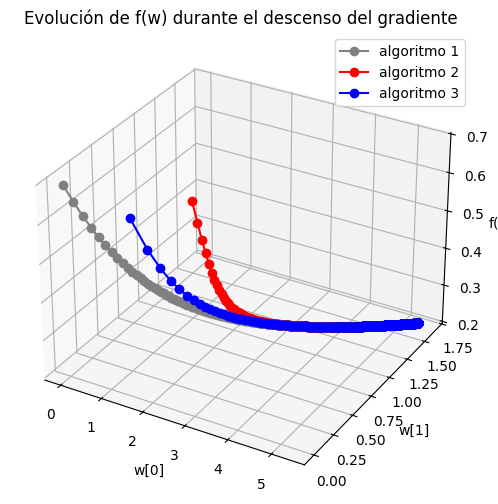

In [200]:
# Extraer resultados
pesos1 = algoritmo1[0]         # Lista de vectores w = [w0, w1, w2]
valores_f1 = algoritmo1[1]     # Lista de valores de f(w)

pesos2 = algoritmo2[0]         # Lista de vectores w = [w0, w1, w2]
valores_f2 = algoritmo2[1]     # Lista de valores de f(w)

pesos3 = algoritmo3[0]         # Lista de vectores w = [w0, w1, w2]
valores_f3 = algoritmo3[1]     # Lista de valores de f(w)

# Convertimos a arrays para poder indexar columnas
pesos1 = np.array(pesos1)
valores_f1 = np.array(valores_f1)
iteraciones1 = np.arange(len(pesos1))

pesos2 = np.array(pesos2)
valores_f2 = np.array(valores_f2)
iteraciones2 = np.arange(len(pesos2))

pesos3 = np.array(pesos3)
valores_f3 = np.array(valores_f3)
iteraciones3 = np.arange(len(pesos3))

# Graficar en 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pesos1[:, 0], pesos1[:, 1], valores_f1, marker='o', linestyle='-', color='gray', label = 'algoritmo 1')
ax.plot(pesos2[:, 0], pesos2[:, 1], valores_f2, marker='o', linestyle='-', color='red', label = 'algoritmo 2')
ax.plot(pesos3[:, 0], pesos3[:, 1], valores_f3, marker='o', linestyle='-', color='blue', label = 'algoritmo 3')

ax.set_xlabel('w[0]')
ax.set_ylabel('w[1]')
ax.set_zlabel('f(w)')
ax.set_title('Evolución de f(w) durante el descenso del gradiente')
ax.legend()

plt.show()


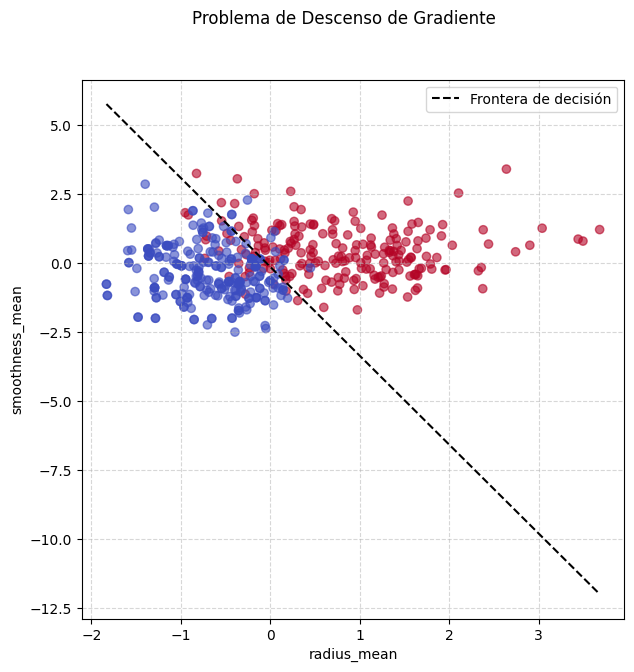

In [201]:
# Definición de variable mejor_w como el mejor w (optimizado) para el algoritmo # 3
mejor_w_3 = res.x  # grafica la mejor opción para el algoritmo # 3

# Función para dibujar las rectas
def plot_lines(w):
  x_vals = np.linspace(data['radius_mean'].min(), data['radius_mean'].max(), 400)
  y_vals = -(w[0] * x_vals + w[2]) / w[1]
  plt.plot(x_vals, y_vals, label='Frontera de decisión', color='black', linestyle='--')
  return

# Función para dibujar los puntos de data (gráfico scatter)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.scatter(data['radius_mean'], data['smoothness_mean'], c=data['pronostic'], cmap = 'coolwarm', alpha = 0.6)
plot_lines(mejor_w_1)

ax.set_xlabel('radius_mean')
ax.set_ylabel('smoothness_mean')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle('Problema de Descenso de Gradiente')
plt.show()

Algoritmo de Descenso de Gradiente Estocastico:

In [202]:
def desc_grad_estocastico(x0, alpha, Nmax, epsilon, data):
    hist = [x0]
    hist_fun = [funcion_objetivo(x0, data)]
    converge = False
    k = 0
    m = len(data)  # Número de muestras

    w = x0.copy()

    while k <= Nmax:
        # Selecciona una muestra aleatoria
        i = np.random.randint(m)
        xi = data.iloc[i, :-1].values
        ti = data.iloc[i, -1]
        zi = np.append(xi, 1)

        # Calcular y_i y gradiente
        yi = 1 / (1 + np.exp(-np.dot(w, zi)))
        yi = np.clip(yi, 1e-15, 1 - 1e-15)

        grad_i = (yi - ti) * zi

        # Actualizar pesos con la muestra seleccionada
        w_new = w - alpha * grad_i
        hist.append(w_new)
        hist_fun.append(funcion_objetivo(w_new, data))

        # Verificar convergencia
        if np.linalg.norm(w_new - w) <= epsilon:
            converge = True
            break

        w = w_new
        k += 1

    return hist, hist_fun, converge


In [203]:
x0 = np.array([0, 0, 0])
alpha = 0.2
Nmax = 3000
epsilon = 0.000000001
algoritmo_desc_est = desc_grad_estocastico(x0, alpha, Nmax, epsilon, data)
print("Minimizador encontrado:\n",algoritmo_desc_est[0][-1])

Minimizador encontrado:
 [5.04992148 1.78963588 0.08837132]


In [204]:
mejor_w_4 = (algoritmo_desc_est[0][-1])
print(mejor_w_4)

[5.04992148 1.78963588 0.08837132]


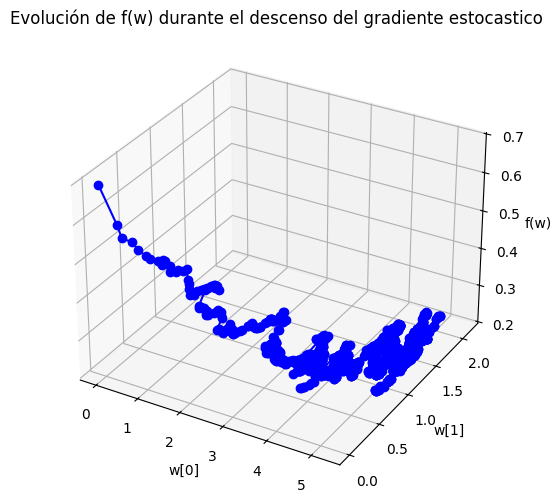

In [205]:
# Extraer resultados
pesos = algoritmo_desc_est[0]         # Lista de vectores w = [w0, w1, w2]
valores_f = algoritmo_desc_est[1]     # Lista de valores de f(w)

# Convertimos a arrays para poder indexar columnas
pesos = np.array(pesos)
valores_f = np.array(valores_f)
iteraciones = np.arange(len(pesos))

# Graficar en 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pesos[:, 0], pesos[:, 1], valores_f, marker='o', linestyle='-', color='blue')

ax.set_xlabel('w[0]')
ax.set_ylabel('w[1]')
ax.set_zlabel('f(w)')
ax.set_title('Evolución de f(w) durante el descenso del gradiente estocastico')

plt.show()


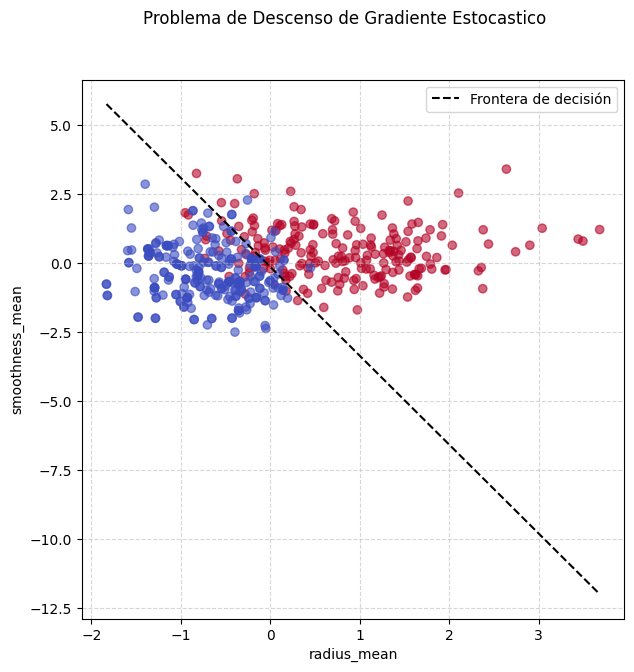

In [206]:
# Definición de variable mejor_w como el mejor w (optimizado)
mejor_w_4 = res.x

# Función para dibujar las rectas
def plot_lines(w):
  x_vals = np.linspace(data['radius_mean'].min(), data['radius_mean'].max(), 400)
  y_vals = -(w[0] * x_vals + w[2]) / w[1]
  plt.plot(x_vals, y_vals, label='Frontera de decisión', color='black', linestyle='--')
  return

# Función para dibujar los puntos de data (gráfico scatter)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.scatter(data['radius_mean'], data['smoothness_mean'], c=data['pronostic'], cmap = 'coolwarm', alpha = 0.6)
plot_lines(mejor_w_1)

ax.set_xlabel('radius_mean')
ax.set_ylabel('smoothness_mean')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle('Problema de Descenso de Gradiente Estocastico')
plt.show()